### Pixel-Based Feature Extraction Methods 

Used to to capture the spatial distribution of color in an image 

#### Colour Descriptors
- Colour Histograms
- Colour Moments Vector
- Colour Palette Extraction


**Colour Histograms**

Each curve represents distribution of pixel intensities for R, G, B (0-255 mapped into bins). Normalised frequency means the histogram was scaled so the values show proportions - not raw counts (it is unitless). 

Types of curve distributions and what they say about the painting: 
- Dominance: means the colour channel has high intensity across most of the range of bins, meaning that the painting contains a lot of tones that branch from this colour e.g. sea scapes will have a dominant blue channel.
- Presence: means that  the colour channel peaks around the middle bins which indicates that the colour is semi-dominant in the painting e.g. landscapes including trees, grass, etc...  
- Highlights/Shadows: significant rise in higher/lower bins, respectively. These are usually accents in a painting.
- Overlap: shows where colours are mixed e.g. purple, brown, grey, etc... Hence, a lot of overlap with blue and green; cool tones and overlap with red; warm tones. 

To describe the colour tone of a painting from these histogram plots, one can evaluate the above 3 curve types to indicate wether it is a warm/cool tone, balanced tones, and contrasts. 

**Colour Moments**

This a feature vector with a compact numerical representation of the color distribution of the painting - summary of the colour distribution. 

First three moments of a probability distribution for each colour channel: 
- Mean: average intensity of a the channel, thus overall brightness of the channel ranges from. Range: 0-255; 0-50 - dark tones i.e. shadows/deep tones, 51-150 - midtones i.e. balanced, not too dark/bright, 151-255 bright tones i.e. highlights/bright regions. 
- Standard Deviation: spread/contrast of a channel i.e. higher values indicate more variation in that colour e.g. many shades of red in a sunset painting. Range: 0-127; 0–20 - flat/ low variation, uniform channel with little contrast, 21–60 - moderate variation, noticable contrast, 61–127 - high variation with a wide spread of values and strong contrast.
- Skewness: asymmetric distribution i.e. +ve skew - more low values, darker tones and -ve skew - more high values, lighter tones. Range: −100 to +100 depending on implementation; approx. 0 - symmetric distribution, balanced light and dark, <0 - skewed toward light values, more high intensity pixels thus overall brighter channel, >0 - skewed toward dark values, more low intensity pixels thus overall darker channel.

These represent the 1st, 2nd and 3rd moments, respectively.
e.g. [R_mean, R_std, R_skew, G_mean, G_std, G_skew, B_mean, B_std, B_skew]

Used for image retrieval, classification, and comparison.

**Extracted Colour Palette**

Using K-Means clustering the top 10 most populated clusters from an image will be present in the colour pallette, indicating the most popular colours. 

In [1]:
# all necessary imports are listed below
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


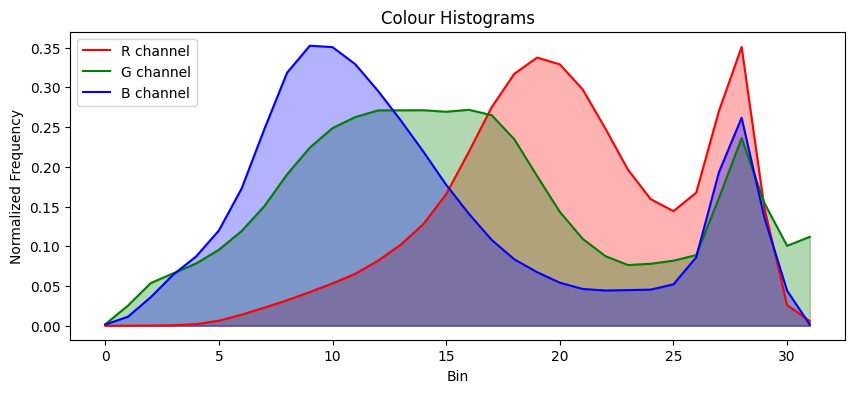

[3.3068225e-06, 5.125575e-05, 0.00018352865, 0.0006101087, 0.001965906, 0.00630115, 0.0138704665, 0.022711257, 0.03209767, 0.042388503, 0.053284485, 0.065361, 0.08185047, 0.101957604, 0.12798725, 0.16566189, 0.2190059, 0.27493253, 0.31715074, 0.33753896, 0.3290057, 0.29773968, 0.24848126, 0.19642195, 0.15930782, 0.14422044, 0.16734506, 0.27010456, 0.35091338, 0.14871773, 0.025918875, 0.005905985, 0.0018617291, 0.02536263, 0.053651113, 0.06605611, 0.078419946, 0.095620364, 0.1191781, 0.15049239, 0.19047056, 0.22412866, 0.24880147, 0.26258808, 0.27106187, 0.27113634, 0.27123237, 0.26934516, 0.27179286, 0.26504555, 0.23465821, 0.1884599, 0.14336686, 0.1095559, 0.08769724, 0.07639752, 0.07798881, 0.08183573, 0.088910304, 0.1606045, 0.23609665, 0.15445493, 0.10058628, 0.11187816, 0.0014533214, 0.011371234, 0.035922047, 0.06452502, 0.08725175, 0.11994362, 0.17271265, 0.24747564, 0.31848025, 0.35244706, 0.35071218, 0.32917118, 0.29568183, 0.25851634, 0.21901082, 0.17740141, 0.14090747, 0.1081

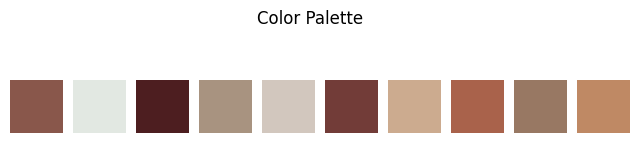

Palette type: Warm
Colour moments vector: [167.05121376  42.86209748 -26.83813164 131.90165986  60.01263363
  40.86190542 116.54753021  60.14168033  54.18512479]


In [ ]:
# classify what type of colour palatte an image has (warm/cold/black and white etc...)
def classify_palette(palette):
    palette_norm = palette / 255.0
    warm_count, cool_count, gray_count = 0, 0, 0
    
    for color in palette_norm:
        r, g, b = color
        
        # if all channels are very close, check for greyscale/neutral
        if abs(r - g) < 0.1 and abs(r - b) < 0.1 and abs(g - b) < 0.1:
            gray_count += 1
            continue
        
        # convert to HSV for warm/cool tone check
        hsv = cv2.cvtColor(np.uint8([[color*255]]), cv2.COLOR_RGB2HSV)[0][0]
        h = hsv[0] 
        
        # hue in [0, 180] 
        if (0 <= h <= 20) or (160 <= h <= 180):  # reds
            warm_count += 1
        elif 20 < h <= 50:  # yellows/oranges
            warm_count += 1
        elif 50 < h <= 130:  # greens/blues
            cool_count += 1
        elif 130 < h < 160:  # purples/magentas
            cool_count += 1
    
    total = warm_count + cool_count + gray_count
    
    if gray_count == total:
        return "Black and White / Grayscale"
    elif warm_count > cool_count and warm_count >= total * 0.5:
        return "Warm"
    elif cool_count > warm_count and cool_count >= total * 0.5:
        return "Cool "
    else:
        return "Mixed / Balanced "
    
#    
def extract_colour_features(image_rgb, k=10, hist_size = 32):
    # compute and plot normalized histograms for R, G, B channels
    hist_range = (0, 256)
    colours = ['r', 'g', 'b']

    # calculate histogram per channel 
    hist_features = []
    hists = []
    for i, col in enumerate(colours):
        hist = cv2.calcHist([image_rgb], [i], None, [hist_size], hist_range)
        hist = cv2.normalize(hist, hist).flatten()
        hists.append(hist)
        hist_features.extend(hist)
    
    # compute colour moments for each channel
    chans = cv2.split(image_rgb)
    features = []
    for chan in chans:
        mean = np.mean(chan)
        std = np.std(chan)
        third_moment = np.mean((chan - mean) ** 3)
        skew = np.cbrt(third_moment)
        features.extend([mean, std, skew])
    moments =  np.array(features)

    # K-Means clustering to find the most popular colours - extract a colour palette
    pixels = image_rgb.reshape(-1, 3)
    kmeans = KMeans(n_clusters=k, random_state=42).fit(pixels)
    colors = kmeans.cluster_centers_.astype(int)
    palette = colors

    classify_palette(palette)

    return moments, palette, hist, hists, hist_features, colours

moments, palette, hist, hists, hist_features, colours = extract_colour_features(image_rgb)

# Output results for colour histogram, colour moments vector, and pallette
plt.figure(figsize=(10, 4))
for hist, col in zip(hists, colours):
    plt.plot(hist, color=col, label=f'{col.upper()} channel')
    plt.fill_between(range(len(hist)), hist, alpha=0.3, color=col)

plt.title("Colour Histograms")
plt.xlabel("Bin")
plt.ylabel("Normalized Frequency")
plt.legend()
plt.show()

print(hist_features)

plt.figure(figsize=(8, 2))
for i, color in enumerate(palette):
    plt.subplot(1, 10, i+1)
    plt.imshow([[color/255]])  
    plt.axis("off")
plt.suptitle("Color Palette")
plt.show()

palette_type = classify_palette(palette)
print("Palette type:", palette_type)
print("Colour moments vector:", moments)